# Auditing the scoring model

The model ships and the reasoning holds, but two of its six drivers don't behave
the way their weights suggest. This notebook shows why, with the actual numbers.

Run `python -m src.modelo` first to generate `results/`.

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src.config import WEIGHTS

ranking = pd.read_csv("../results/ranking_secciones.csv", dtype={"seccion_censal": str})
top50 = pd.read_csv("../results/top_50_secciones.csv", dtype={"seccion_censal": str})

print(f"{len(ranking):,} census sections scored")
print(f"score ranges {ranking.puntuacion_final.min():.3f} to {ranking.puntuacion_final.max():.3f}")

35,891 census sections scored
score ranges 0.115 to 0.641


## 1. Nominal weight vs. delivered contribution

A weight only matters if the variable it multiplies actually varies. The honest
measure of a driver's influence is `weight x mean(value)` — what it contributes
to a typical score.

In [2]:
aporte = pd.DataFrame({
    "weight": pd.Series(WEIGHTS),
    "mean_value": ranking[list(WEIGHTS)].mean(),
})
aporte["contribution"] = aporte.weight * aporte.mean_value
aporte["share_of_score"] = aporte.contribution / aporte.contribution.sum()
aporte.sort_values("share_of_score", ascending=False).style.format({
    "weight": "{:.4f}", "mean_value": "{:.3f}",
    "contribution": "{:.4f}", "share_of_score": "{:.1%}",
})

,weight,mean_value,contribution,share_of_score
poblacion_ideal_norm,0.1600,0.891,0.1425,39.3%
ccaa_norm,0.2250,0.460,0.1036,28.6%
generacion_norm,0.1000,0.498,0.0498,13.8%
renta_hogar_norm,0.1700,0.236,0.0402,11.1%
no_potabilidad_norm,0.2125,0.105,0.0223,6.1%
sequia_norm,0.1325,0.030,0.0039,1.1%


`sequia_norm` is nominally worth 13.25% of the score. Look at what it actually
delivers — it is roughly an order of magnitude below its billing, while
`poblacion_ideal_norm` punches well above its weight because nearly every
section scores high on it (so it barely separates anyone either).

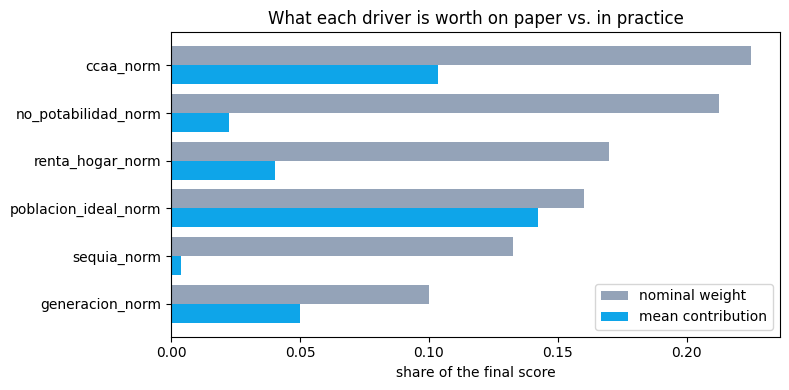

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
orden = aporte.sort_values("weight", ascending=True)
y = range(len(orden))
ax.barh([i + 0.2 for i in y], orden.weight, height=0.4, label="nominal weight", color="#94a3b8")
ax.barh([i - 0.2 for i in y], orden.contribution, height=0.4, label="mean contribution", color="#0ea5e9")
ax.set_yticks(list(y)); ax.set_yticklabels(orden.index)
ax.set_xlabel("share of the final score"); ax.legend()
ax.set_title("What each driver is worth on paper vs. in practice")
plt.tight_layout()

## 2. Why drought is switched off

`puntuacion_sequia` is extremely right-skewed: a handful of stations sit two
orders of magnitude above the median. Min-max scaling maps that whole tail onto
[0, 1], which crushes everyone else against zero.

In [4]:
print(ranking.sequia_norm.describe(percentiles=[0.5, 0.9, 0.99]).to_string())
print()
print(f"sections below 0.05: {(ranking.sequia_norm < 0.05).mean():.1%}")

count    35891.000000
mean         0.029633
std          0.130067
min          0.000000
50%          0.001089
90%          0.011090
99%          0.801521
max          1.000000

sections below 0.05: 95.0%


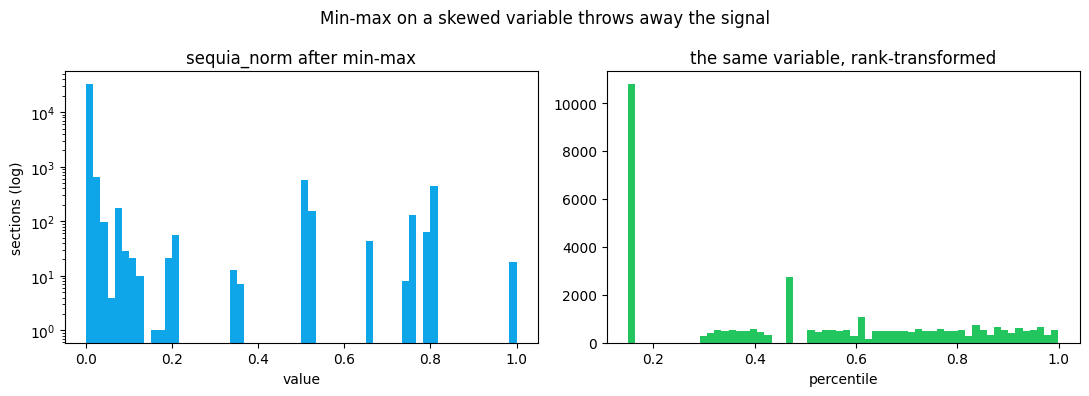

In [5]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
a.hist(ranking.sequia_norm, bins=60, color="#0ea5e9")
a.set_yscale("log"); a.set_title("sequia_norm after min-max"); a.set_xlabel("value")
a.set_ylabel("sections (log)")

rank_transform = ranking.sequia_norm.rank(pct=True)
b.hist(rank_transform, bins=60, color="#22c55e")
b.set_title("the same variable, rank-transformed"); b.set_xlabel("percentile")
fig.suptitle("Min-max on a skewed variable throws away the signal")
plt.tight_layout()

Left: 95% of sections are pinned near zero, so the driver can't separate them.
Right: a rank transform spreads the same information across the full range and
would let the 13.25% weight mean what it says. That's the first fix I'd make.

## 3. The regional term decides the region

In [6]:
regional = (ranking.groupby("ccaa")
            .agg(ccaa_norm=("ccaa_norm", "first"),
                 sections=("seccion_censal", "size"),
                 in_top50=("puntuacion_final", lambda s: s.nlargest(0).size))
            .sort_values("ccaa_norm", ascending=False))
regional["in_top50"] = top50.ccaa.value_counts().reindex(regional.index).fillna(0).astype(int)
regional

,ccaa_norm,sections,in_top50
ccaa,,,
Cataluña,1.000000,5079,47
C. Valenciana,0.716406,3473,0
Andalucía,0.682371,5903,3
C. de Madrid,0.358132,4413,0
Canarias,0.312685,1382,0
Galicia,0.311991,2149,0
Islas Baleares,0.278954,410,0
Región de Murcia,0.274960,1192,0
Castilla-La Mancha,0.235273,1948,0


`ccaa_norm` carries the largest weight (0.225) and takes only 19 values.
Cataluña scores exactly 1.0, so every Catalan section opens with a flat +0.225
that no section elsewhere can close on local merit — hence 47 of the top 50.
The model picks a region, then sorts within it.

In [7]:
ventaja = 0.225 * (1.0 - regional.ccaa_norm)
banda = top50.puntuacion_final.max() - top50.puntuacion_final.min()

print("Head start Cataluña gets over each region, before any local factor:")
print(ventaja.round(3).to_string())
print(f"\nThe whole top 50 fits inside a band of {banda:.3f}.")
print("So to displace a Catalan section, a section elsewhere must beat it on the")
print("other five drivers by more than its regional gap -- for most regions that")
print("gap is twice the entire spread of the top 50.")

Head start Cataluña gets over each region, before any local factor:
ccaa
Cataluña              0.000
C. Valenciana         0.064
Andalucía             0.071
C. de Madrid          0.144
Canarias              0.155
Galicia               0.155
Islas Baleares        0.162
Región de Murcia      0.163
Castilla-La Mancha    0.172
Castilla y León       0.185
Extremadura           0.186
País Vasco            0.195
Cantabria             0.197
Asturias              0.201
Aragón                0.202
Melilla               0.209
Ceuta                 0.210
Navarra               0.216
La Rioja              0.225

The whole top 50 fits inside a band of 0.071.
So to displace a Catalan section, a section elsewhere must beat it on the
other five drivers by more than its regional gap -- for most regions that
gap is twice the entire spread of the top 50.


Only Andalucía comes close, with a gap (0.071) that happens to equal the spread
of the whole top 50 — and the three Andalusian sections that make it are all in
Viator, which has the hardest tap water in Spain. Every other region needs its
sections to out-perform Cataluña's by more than the top 50's entire range,
purely to compensate for a term that has nothing to do with the section itself.

## 4. Where the 50 actually are

In [8]:
resumen = (top50.groupby(["ccaa", "municipio"])
           .agg(sections=("seccion_censal", "size"), best=("puntuacion_final", "max"))
           .sort_values("sections", ascending=False))
resumen

sections      best
ccaa      municipio                                
Cataluña  Sant Cugat del Vallès        16  0.572266
          Banyoles                     12  0.632314
          Vallirana                    10  0.631192
Andalucía Viator                        3  0.594084
Cataluña  Gandesa                       2  0.581474
          Bellmunt del Priorat          1  0.640804
          Cabrera d'Anoia               1  0.579700
          Forès                         1  0.608623
          Mediona                       1  0.592648
          Pira                          1  0.596064
          Prat de Comte                 1  0.617764
          Torà                          1  0.605111

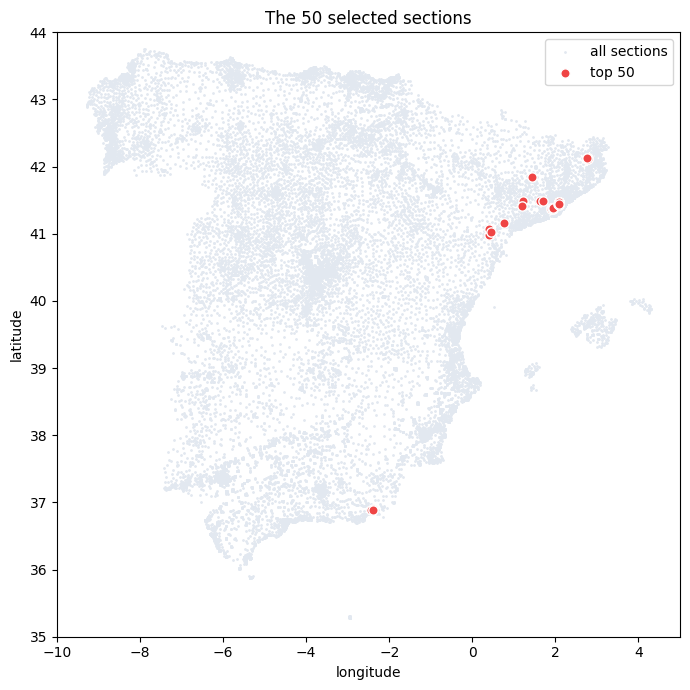

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ranking.longitud, ranking.latitud, s=1, c="#e2e8f0", label="all sections")
ax.scatter(top50.longitud, top50.latitud, s=45, c="#ef4444", edgecolor="white", label="top 50")
ax.set_xlim(-10, 5); ax.set_ylim(35, 44)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("The 50 selected sections"); ax.legend()
plt.tight_layout()

Clustered, not spread. Sixteen sections in Sant Cugat del Vallès and twelve in
Banyoles: a tight launch corridor if that's the goal, a poor national footprint
if it isn't. The model was never told which one we wanted — that preference
belongs in the objective, not in a post-hoc reading of the output.